# FeAl Volume Optimization — Equation of State

Sweeps unit-cell volume for FeAl, runs a Quantum ESPRESSO SCF at each volume, and fits an equation of state (EoS) to the resulting E-V curve.

Results are written to disk after every run so progress survives a kernel restart or a failed calculation partway through the sweep.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from ase.calculators.espresso import Espresso, EspressoProfile
from ase.eos import EquationOfState
from ase.io import read
from ase.units import GPa, Ry

## 1. Load the structure

In [2]:
atoms = read("FeAl.cif")
orig_cell = atoms.get_cell().copy()
orig_scaled_positions = atoms.get_scaled_positions().copy()
orig_volume = atoms.get_volume()

print(orig_cell)
print(orig_volume)
print(orig_scaled_positions)

Cell([2.7061, 4.41901, 4.6871])
56.04966806650307
[[0.75       0.75       0.91666667]
 [0.25       0.25       0.08333333]
 [0.25       0.75       0.41666667]
 [0.75       0.25       0.58333333]]


## 2. Calculator configuration

For medium precision calculations, use `ecutwfc=70 Ry`, `ecutrho=700 Ry`, k-mesh `6x4x4`. For high precision calculations (which take more computer time), use `ecutwfc=90 Ry`, `ecutrho=900 Ry`, k-mesh `14x8x8`. It will always be indicated when it is safe to use medium precision.

In [3]:
pseudo_dir = str(Path("CMP_pseudos").resolve())
pseudopotentials = {"Al": "Al.pbe-n-kjpaw_psl.0.1.UPF",
                    "Fe": "Fe.pbe-spn-kjpaw_psl.0.2.1.UPF"}

input_data = {
    'control': {
        'calculation': 'scf',       # Options: 'scf', 'relax', 'vc-relax'
        'prefix': 'FeAl',              # Prefix for input/output files
        'verbosity': 'low',
        "pseudo_dir": pseudo_dir,  # Directory for pseudopotentials
        'tprnfor': True,
        'tstress': True,
        'outdir': '.',          # Directory for scratch files
    },
    'system': {
        'ecutwfc': 70.0,            # Wavefunction cutoff in Ry
        'ecutrho': 700.0,          # Charge density cutoff in Ry
        'occupations': 'smearing',
        'smearing': 'mv',
        'degauss': 0.005,
    },
    'electrons': {
        'conv_thr': 1e-08,         # Convergence threshold
        'mixing_beta': 0.7,
    }
}
kpts = (6, 4, 4)  # k-point mesh

## 3. Volume range sweep

Each volume factor runs `pw.x` in its own subdirectory (`vol_<factor>/`) so `espresso.pwo`/`espresso.pwi` don't collide between runs. After every iteration the accumulated results are written to `volume_sweep_results.json`, so a crash or interrupted run doesn't lose already-completed points.

In [ ]:
vol_range = [0.8, 0.85, 0.9, 0.95, 1.0]
results_path = Path("volume_sweep_results.json")

results = {"volume": [], "energy": []}

for i, volume_factor in enumerate(vol_range):
    print(f"{i+1}/{len(vol_range)}. Volume factor: {volume_factor}")
    lin_frac = volume_factor ** (1 / 3)
    atoms.set_cell(orig_cell * lin_frac, scale_atoms=True)

    run_dir = Path(f"vol_{volume_factor:.2f}")
    run_dir.mkdir(exist_ok=True)

    profile = EspressoProfile(command='pw.x', pseudo_dir=pseudo_dir)
    atoms.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials,
                        kpts=kpts, input_data=input_data,
                        directory=run_dir)

    try:
        energy_eV = atoms.get_potential_energy()  # runs pw.x and parses the SCF total energy
        energy_Ry = energy_eV / Ry
        volume = atoms.get_volume()
    except Exception as e:
        print(f"Error during calculation: {e}")
        energy_Ry = None
        volume = None
    else:
        (run_dir / "espresso.err").unlink(missing_ok=True)
        (run_dir / "espresso.pwi").unlink(missing_ok=True)

    if energy_Ry is not None:
        print(f"Total energy: {energy_Ry:.6f} Ry")
        print(f"Volume: {volume:.6f} A^3")
    else:
        print("Run failed, no energy recorded.")

    results["volume"].append(volume)
    results["energy"].append(energy_Ry)

    # Persist after every run so progress survives a crash/interrupt.
    results_path.write_text(json.dumps(results, indent=2))

print(f"Saved sweep results to {results_path.resolve()}")

## 4. E-V curve

In [4]:
volumes = np.array(results["volume"], dtype=float)
energies_Ry = np.array(results["energy"], dtype=float)

plt.plot(volumes, energies_Ry, 'o-')
plt.xlabel('Volume (A^3)')
plt.ylabel('Energy (Ry)')
plt.title('Volume Optimization')
plt.savefig("ev_curve.png", dpi=150)
plt.show()

NameError: name 'results' is not defined

## 5. Equation of state fit

Fits a Birch-Murnaghan EoS to the E-V curve using ASE's built-in `ase.eos.EquationOfState` (no external `ev.x` needed) and saves the fitted parameters alongside a plot.

V0 = 48.9399 A^3
E0 = -10034.793382 eV
B0 = 170.55 GPa


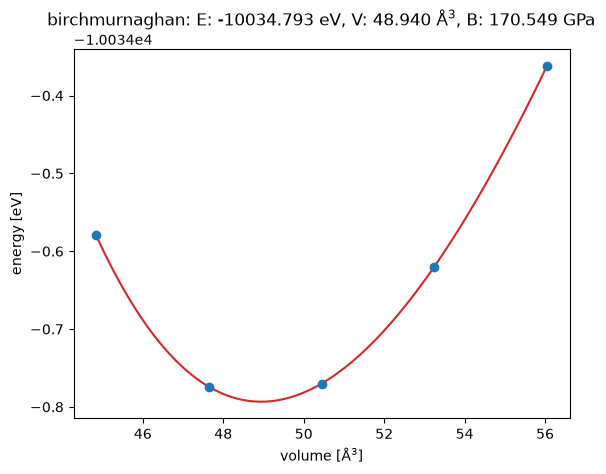

Saved EoS fit results to eos_fit_results.json


In [4]:
energies_Ry = np.array([-737.528017,-737.542305,-737.541999,-737.530955,-737.511980])
energies_eV = energies_Ry * Ry  # ase.eos expects eV
volumes = np.array([44.839734,47.642218,50.444701,53.247185,56.049668])

eos = EquationOfState(volumes, energies_eV, eos='birchmurnaghan')
v0, e0, B = eos.fit()

print(f"V0 = {v0:.4f} A^3")
print(f"E0 = {e0:.6f} eV")
print(f"B0 = {B / GPa:.2f} GPa")

eos.plot('eos_fit.png')
plt.show()

eos_summary = {"V0_A3": v0, "E0_eV": e0, "B0_GPa": B / GPa}
Path("eos_fit_results.json").write_text(json.dumps(eos_summary, indent=2))
print("Saved EoS fit results to eos_fit_results.json")

## 6. Constant-volume b/a ratio scan

FeAl.cif is orthorhombic (a=2.7061, b=4.41901, c=4.6871 A, all angles 90 deg), so unlike the isotropic volume sweep above, we can also scan the *shape* of the cell at fixed volume — a standard way to map out the energy landscape of an orthorhombic distortion.

`Atoms`/`Cell` has no built-in "hold volume, scan a ratio" helper, so the three lattice lengths are computed by hand. Volume (`a*b*c = V0`) and a target ratio (`b/a`) only give 2 equations for 3 unknowns, so a third constraint is needed to pin down the solution. Here we hold `c/a` fixed at its original value and solve for `a`, `b`, `c`:

```
c/a = c0/a0                        (fixed)
a = (V0 / (ratio * (c0/a0)))^(1/3)
b = ratio * a
c = (c0/a0) * a
```

Each lattice vector of `orig_cell` is then rescaled along its own direction by `a/a0`, `b/b0`, `c/c0` respectively (this stays correct even if the cell isn't axis-aligned). As in the volume sweep, each ratio runs `pw.x` in its own subdirectory and results are persisted after every point.</cell id="cell-11">

In [7]:
a0, b0, c0 = orig_cell.lengths()
c_over_a0 = c0 / a0
orig_ratio = b0 / a0

ratio_factors = [0.97,0.98,0.99,1.00,1.01,1.02,1.03,1.04]
ratio_range = [f * orig_ratio for f in ratio_factors]
ratio_results_path = Path("ratio_sweep_results.json")

if ratio_results_path.exists():
    ratio_results = json.loads(ratio_results_path.read_text())
    print(f"Loaded cached ratio sweep results from {ratio_results_path.resolve()}")
else:
    ratio_results = {"ratio": [], "volume": [], "energy": []}

    for i, target_ratio in enumerate(ratio_range):
        print(f"{i+1}/{len(ratio_range)}. b/a ratio: {target_ratio:.4f}")

        a_new = (v0 / (target_ratio * c_over_a0)) ** (1 / 3)
        b_new = target_ratio * a_new
        c_new = c_over_a0 * a_new

        new_cell = orig_cell.copy()
        new_cell[0] *= a_new / a0
        new_cell[1] *= b_new / b0
        new_cell[2] *= c_new / c0
        atoms.set_cell(new_cell, scale_atoms=True)

        run_dir = Path("out") / f"ratio_{target_ratio:.4f}"
        run_dir.mkdir(exist_ok=True)

        profile = EspressoProfile(command='pw.x', pseudo_dir=pseudo_dir)
        atoms.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials,
                            kpts=kpts, input_data=input_data,
                            directory=run_dir)

        try:
            energy_eV = atoms.get_potential_energy()  # runs pw.x and parses the SCF total energy
            energy_Ry = energy_eV / Ry
            volume = atoms.get_volume()
        except Exception as e:
            print(f"Error during calculation: {e}")
            energy_Ry = None
            volume = None
        else:
            (run_dir / "espresso.err").unlink(missing_ok=True)
            (run_dir / "espresso.pwi").unlink(missing_ok=True)

        if energy_Ry is not None:
            print(f"Total energy: {energy_Ry:.6f} Ry")
            print(f"Volume: {volume:.6f} A^3 (target {v0:.6f} A^3)")
        else:
            print("Run failed, no energy recorded.")

        ratio_results["ratio"].append(target_ratio)
        ratio_results["volume"].append(volume)
        ratio_results["energy"].append(energy_Ry)

        # Persist after every run so progress survives a crash/interrupt.
        ratio_results_path.write_text(json.dumps(ratio_results, indent=2))

    print(f"Saved ratio sweep results to {ratio_results_path.resolve()}")

Loaded cached ratio sweep results from /home/yluo/ASE/05_volume_optimization/ratio_sweep_results.json


## 7. Energy vs. b/a ratio curve

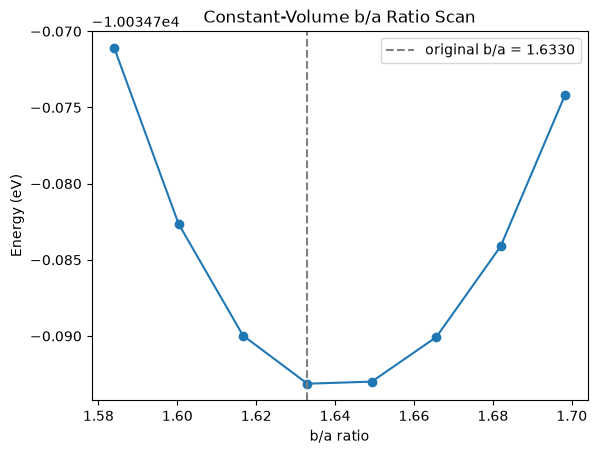

In [8]:
ratios = np.array(ratio_results["ratio"], dtype=float)
ratio_energies_Ry = np.array(ratio_results["energy"], dtype=float)
ratio_energies_eV = ratio_energies_Ry * Ry 
plt.plot(ratios, ratio_energies_eV, 'o-')
plt.axvline(orig_ratio, color='gray', linestyle='--', label=f'original b/a = {orig_ratio:.4f}')
plt.xlabel('b/a ratio')
plt.ylabel('Energy (eV)')
plt.title('Constant-Volume b/a Ratio Scan')
plt.legend()
plt.savefig("ratio_curve.png", dpi=150)
plt.show()

## 8. Quadratic fit to the b/a ratio scan

The scan above only samples ratios within +/-4% of the original, so a full EoS-style fit isn't warranted — a quadratic captures the curvature near the minimum well enough. Fitting `E(ratio) = A*ratio^2 + B*ratio + C` with `np.polyfit` and solving the vertex `-B/(2A)` gives the ideal b/a ratio at fixed volume.

Best-fit b/a ratio: 1.6428 (original: 1.6330)
Fitted energy at minimum: -10034.793766 eV


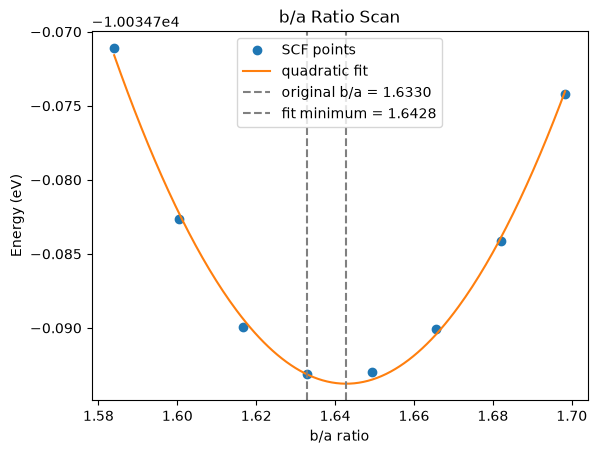

In [9]:
coeffs = np.polyfit(ratios, ratio_energies_eV, 2)
best_ratio = -coeffs[1] / (2 * coeffs[0])
best_energy_eV = np.polyval(coeffs, best_ratio)

print(f"Best-fit b/a ratio: {best_ratio:.4f} (original: {orig_ratio:.4f})")
print(f"Fitted energy at minimum: {best_energy_eV:.6f} eV")

fit_ratios = np.linspace(ratios.min(), ratios.max(), 200)
plt.plot(ratios, ratio_energies_eV, 'o', label='SCF points')
plt.plot(fit_ratios, np.polyval(coeffs, fit_ratios), '-', label='quadratic fit')
plt.axvline(orig_ratio, color='gray', linestyle='--', label=f'original b/a = {orig_ratio:.4f}')
plt.axvline(best_ratio, color='gray', linestyle='--', label=f'fit minimum = {best_ratio:.4f}')
plt.xlabel('b/a ratio')
plt.ylabel('Energy (eV)')
plt.title('b/a Ratio Scan')
plt.legend()
plt.savefig("ratio_quadratic_fit.png", dpi=150)
plt.show()

## 9. Build the optimized cell

Same volume constraint as the scan above (fixed `c/a`, `a*b*c = V0`), solved once at `best_ratio` instead of stepping through a range. `v0` is still the EoS-fit volume from section 5 — the ratio scan and this fit only ever explored cell *shape*, never touched volume.

In [10]:
a_opt = (v0 / (best_ratio * c_over_a0)) ** (1 / 3)
b_opt = best_ratio * a_opt
c_opt = c_over_a0 * a_opt

opt_cell = orig_cell.copy()
opt_cell[0] *= a_opt / a0
opt_cell[1] *= b_opt / b0
opt_cell[2] *= c_opt / c0

atoms.set_cell(opt_cell, scale_atoms=True)

print(f"Optimized lattice lengths: a={a_opt:.4f}, b={b_opt:.4f}, c={c_opt:.4f} A")
print(f"Optimized b/a ratio: {b_opt / a_opt:.4f}")
print(f"Optimized cell volume: {atoms.get_volume():.4f} A^3 (target {v0:.4f} A^3)")

Optimized lattice lengths: a=2.5813, b=4.2406, c=4.4709 A
Optimized b/a ratio: 1.6428
Optimized cell volume: 48.9399 A^3 (target 48.9399 A^3)


## 10. Relax atomic positions

Every calculation so far has been a rigid-lattice `scf`: `set_cell(..., scale_atoms=True)` moves the atoms along with the cell but never lets them settle independently. With the cell shape and volume now fixed at the fitted optimum, run a `relax` calculation (fixed cell, `ion_dynamics: bfgs`) to find the true equilibrium positions. Precision settings — `ecutwfc`, `ecutrho`, k-mesh, smearing, convergence — are copied from `05a_geo_opt/main.ipynb` rather than the `scf` settings used in the sweeps above.

In [11]:
input_data_relax = {
    'control': {
        'calculation': 'relax',       # fixed cell -- only atomic positions move
        'prefix': 'FeAl',
        'verbosity': 'low',
        'pseudo_dir': pseudo_dir,
        'tprnfor': True,
        'tstress': True,
        'outdir': '.',
    },
    'system': {
        'ecutwfc': 70.0,
        'ecutrho': 700.0,
        'occupations': 'smearing',
        'smearing': 'mv',
        'degauss': 0.005,
    },
    'electrons': {
        'conv_thr': 1e-09,
        'mixing_beta': 0.7,
    },
    'ions': {
        'ion_dynamics': 'bfgs',
    },
}
kpts_relax = (6,4,4)

profile = EspressoProfile(command='pw.x', pseudo_dir=pseudo_dir)
atoms.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials,
                    kpts=kpts_relax, input_data=input_data_relax,
                    directory=Path("relax"))

new_energy_eV = atoms.get_potential_energy()
new_positions = atoms.get_scaled_positions()

print(f"Old energy (quadratic fit to b/a scan): {best_energy_eV:.6f} eV")
print(f"New energy (relaxed positions):         {new_energy_eV:.6f} eV")
print(f"Energy lowered by:                      {best_energy_eV - new_energy_eV:.6f} eV")
print("New fractional (scaled) positions:")
print(new_positions)

Old energy (quadratic fit to b/a scan): -10034.793766 eV
New energy (relaxed positions):         -10034.876663 eV
Energy lowered by:                      0.082897 eV
New fractional (scaled) positions:
[[0.75       0.75       0.91666667]
 [0.25       0.25       0.08333333]
 [0.25       0.75       0.41666667]
 [0.75       0.25       0.58333333]]


## 11. Volume-and-shape relaxation (vc-relax)

`atoms.get_potential_energy()` above runs the relax calculation and parses the result into `atoms.calc.results`, but it never writes the relaxed positions back onto `atoms` — note that `new_positions` printed above is identical to the original fractional coordinates. To start from the actual relaxed structure, re-read it from `relax/espresso.pwo` instead of trusting `atoms`.

From that relaxed structure, run a `vc-relax` (cell shape/volume and ion positions all relax together) at higher precision: `ecutwfc=90 Ry`, `ecutrho=900 Ry`, k-mesh `14x8x8`, same convergence/smearing/BFGS settings as the relax step above.

In [12]:
relaxed_atoms = read("relax/espresso.pwo", index=-1)

input_data_vcrelax = {
    'control': {
        'calculation': 'vc-relax',    # cell shape/volume and atomic positions both relax
        'prefix': 'FeAl',
        'verbosity': 'low',
        'pseudo_dir': pseudo_dir,
        'tprnfor': True,
        'tstress': True,
        'outdir': '.',
    },
    'system': {
        'ecutwfc': 90.0,
        'ecutrho': 900.0,
        'occupations': 'smearing',
        'smearing': 'mv',
        'degauss': 0.005,
    },
    'electrons': {
        'conv_thr': 1e-08,
        'mixing_beta': 0.7,
    },
    'ions': {
        'ion_dynamics': 'bfgs',
    },
}
kpts_vcrelax = (14, 8, 8)

profile = EspressoProfile(command='pw.x', pseudo_dir=pseudo_dir)
relaxed_atoms.calc = Espresso(profile=profile, pseudopotentials=pseudopotentials,
                    kpts=kpts_vcrelax, input_data=input_data_vcrelax,
                    directory=Path("vc_relax"))

vcrelax_energy_eV = relaxed_atoms.get_potential_energy()

print(f"Energy after relax (section 10):  {new_energy_eV:.6f} eV")
print(f"Energy after vc-relax:            {vcrelax_energy_eV:.6f} eV")
print(f"Energy lowered by:                {new_energy_eV - vcrelax_energy_eV:.6f} eV")
print("Final cell (A):")
print(relaxed_atoms.get_cell())
print("Final scaled positions:")
print(relaxed_atoms.get_scaled_positions())

Energy after relax (section 10):  -10034.876663 eV
Energy after vc-relax:            -10035.141158 eV
Energy lowered by:                0.264495 eV
Final cell (A):
Cell([2.5813020801969904, 4.240581126462177, 4.470944268005197])
Final scaled positions:
[[0.75000008 0.74999987 0.90248104]
 [0.25000003 0.24999996 0.09751895]
 [0.25000003 0.74999987 0.39418337]
 [0.75000008 0.24999996 0.60581662]]
